### Libraries.

In [1]:
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.special import softmax, log_softmax
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
import torch

import sc_exp_design



### Constants.

In [2]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
USE_CLASS_WEIGHTS = True
USE_PCA = False
CONCATENATE_SCATTER_FEATS = False
STANDARDIZE_FEATURES = False


### Paths.

In [3]:
ADATA_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"


### Reading annotated data.

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Visualizing scatter features distribution.

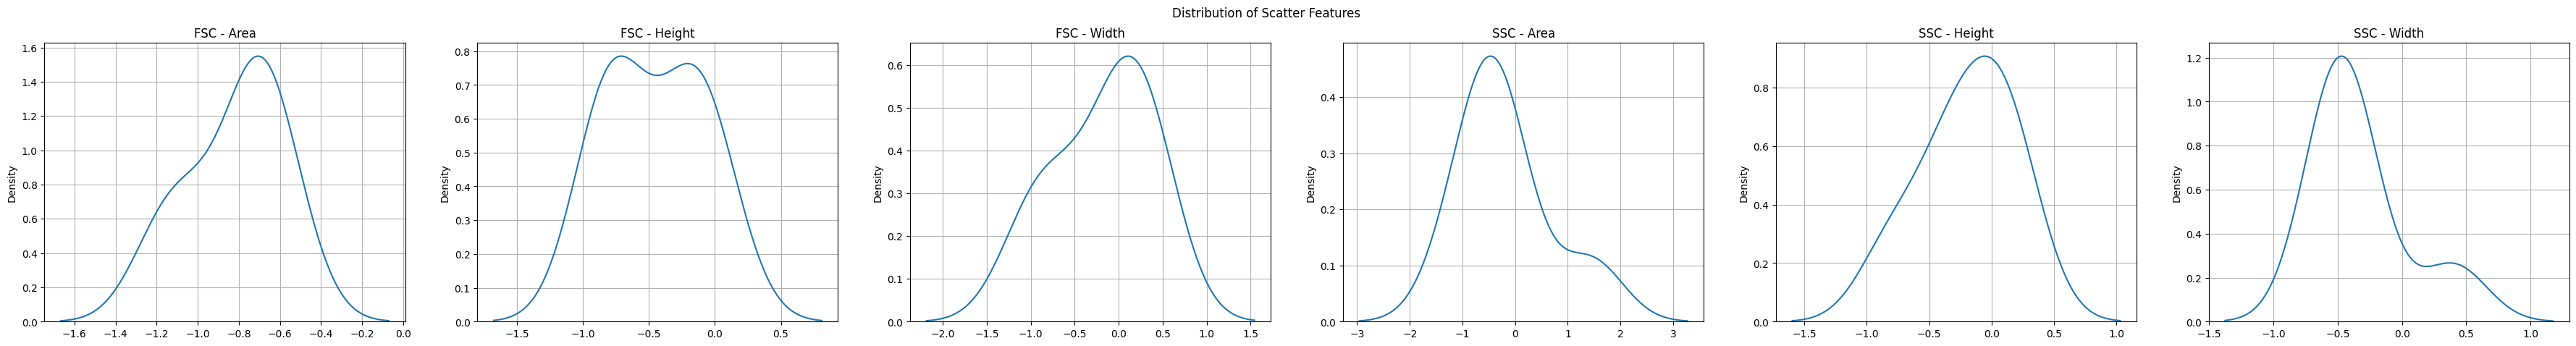

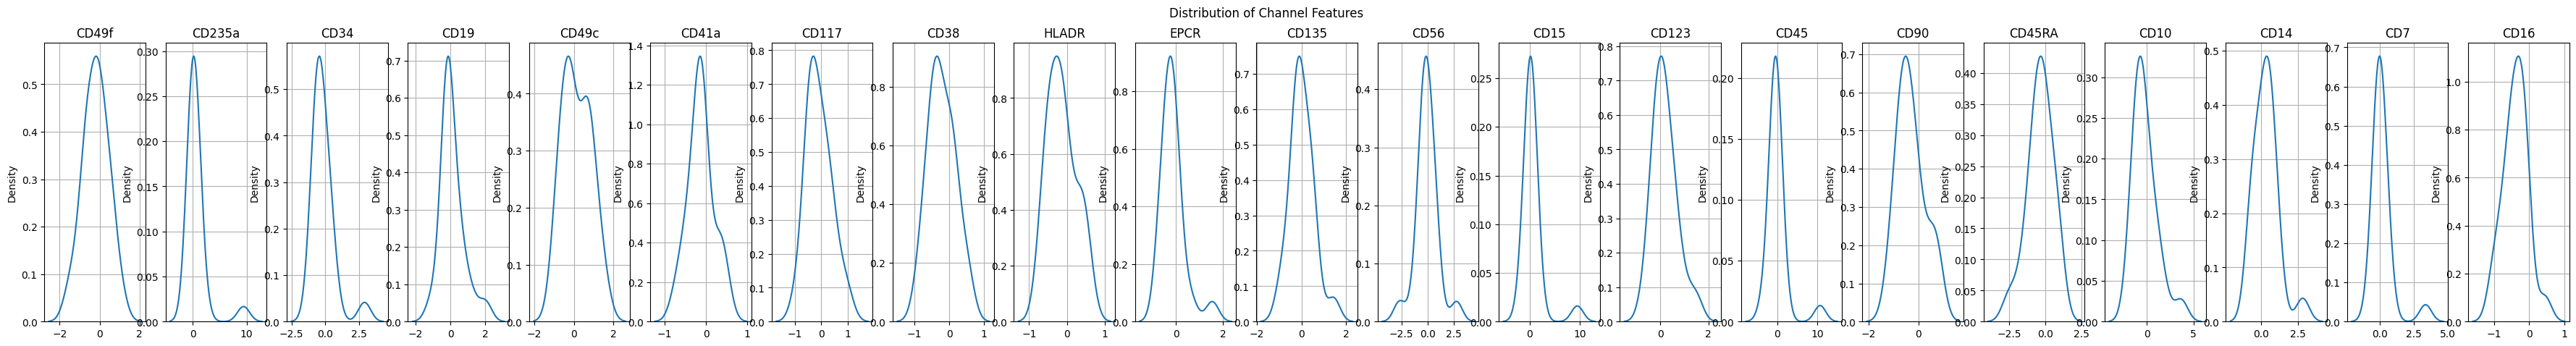

In [5]:
X_scatter = adata.obs[SCATTER_COLUMNS].values
X_scatter.shape

data = (X_scatter - X_scatter.mean(0, keepdims=True))/X_scatter.std(0, keepdims=True)
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Scatter Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(SCATTER_COLUMNS[idx])

data = (adata.X - adata.X.mean(0, keepdims=True)) / adata.X.std(0, keepdims=True)
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("Distribution of Channel Features")
for idx in range(data.shape[1]):
    # antibody = int2antibody[idx]
    sns.kdeplot(data[idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(adata.var_names[idx])


### Label encoder for target.

In [6]:
le_cell_type = LabelEncoder()
le_cell_type.fit(adata.obs["cell_type"].values)


LabelEncoder()

### Splitting the data.

In [7]:
K = 3
test_size = 0.3
skf = ShuffleSplit(n_splits=K, test_size=test_size)
splits = skf.split(np.zeros(len(adata)), adata.obs["cell_type"].values)
(train_index, test_index) = next(iter(splits))
train_adata = adata[train_index]
val_adata = adata[test_index]
train_adata, val_adata


(View of AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
     obsm: 'X_pca', 'X_umap'
     layers: 'positives

### Preparing data.

In [8]:
BATCH_SIZE = 256
dm = sc_exp_design.data.DataManager(
    train_adata,
    sample_rep="X_pca" if USE_PCA else None,
    load_target_covariates=True,
    target_covariates={"cell_type":"label"}
)

train_data = dm.get_data(train_adata)
val_data = dm.get_data(val_adata)
train_dataloader = sc_exp_design.data.SequentialDataLoader(
    train_data,
    BATCH_SIZE,
)

if not isinstance(train_data.state_data, np.ndarray):
    train_data.state_data = train_data.state_data.toarray()
if not isinstance(val_data.state_data, np.ndarray):
    val_data.state_data = val_data.state_data.toarray()

if CONCATENATE_SCATTER_FEATS:
    train_data.state_data = np.concatenate(train_data.state_data, train_data.adata.obs[SCATTER_COLUMNS].values)
if STANDARDIZE_FEATURES:
    train_data.state_data = (train_data.state_data - train_data.state_data.mean(0, keepdims=True))/train_data.state_data.std(0, keepdims=True)
X_train = train_data.state_data
Y_train = train_data.target_data["cell_type"]
Y_train_labels = le_cell_type.inverse_transform(Y_train)

if CONCATENATE_SCATTER_FEATS:
    val_data.state_data = np.concatenate(val_data.state_data, val_data.adata.obs[SCATTER_COLUMNS].values)
if STANDARDIZE_FEATURES:
    val_data.state_data = (val_data.state_data - val_data.state_data.mean(0, keepdims=True))/val_data.state_data.std(0, keepdims=True)
X_val = val_data.state_data
Y_val = val_data.target_data["cell_type"]
Y_val_labels = le_cell_type.inverse_transform(Y_val)


### Fitting MLP.

Loss: 0.2160: 100%|██████████| 50000/50000 [01:32<00:00, 542.37it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

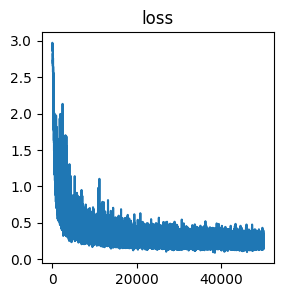

In [9]:
mlp_target_prediction_model = sc_exp_design.networks.PerturbationApproximatePosterior(
    train_data.state_data.shape[1],
    freeze_grads=False,
    target_output_dims={"cell_type": adata.obs.cell_type.nunique()},
    noise_models={"cell_type": None},
    covariate_kwargs={
        "cell_type":{
            "hidden_dims": (32, 32),
            "activation_class": torch.nn.ReLU,
            "use_dropout": False,
            "use_batchnorm": False,
            "final_activation_class": torch.nn.Identity,
        }
    }
)
mlp_target_prediction_model = mlp_target_prediction_model.float()
mlp_target_prediction_model = mlp_target_prediction_model.to("cuda")
# mlp_optimizer = torch.optim.Adam(mlp_target_prediction_model.parameters(), lr=1e-3, weight_decay=1e-3)
mlp_optimizer = torch.optim.Adam(mlp_target_prediction_model.parameters(), lr=1e-3)

NUM_TRAINING_STEPS = 50_000

values = train_adata.obs["cell_type"].values
classes = np.unique(values)
class_weights = torch.from_numpy(compute_class_weight("balanced", classes=np.unique(train_adata.obs["cell_type"].values), y=train_adata.obs["cell_type"].values)).float().to("cuda")

mlp_trainer = sc_exp_design.training.TargetPredictionTrainer(
    mlp_target_prediction_model,
    mlp_optimizer,
    loss_fn_kwargs={"weight":class_weights} if USE_CLASS_WEIGHTS else {}
)
mlp_trainer.fit(
    NUM_TRAINING_STEPS,
    train_dataloader,
)
mlp_trainer.plot_training_logs()


### Running predictions with the model.

In [10]:
# train data
Y_train_pred_logits = mlp_target_prediction_model(torch.from_numpy(X_train).float().cuda())["cell_type"].detach().cpu().numpy()
Y_train_pred_probs = softmax(Y_train_pred_logits, axis=-1)
Y_train_pred_log_probs = log_softmax(Y_train_pred_logits, axis=-1)
Y_train_pred_entropy = -np.sum(Y_train_pred_probs*Y_train_pred_log_probs, axis=-1)
Y_train_pred_id = Y_train_pred_probs.argmax(axis=-1)
Y_train_pred = le_cell_type.inverse_transform(Y_train_pred_id)

# validation data
Y_val_pred_logits = mlp_target_prediction_model(torch.from_numpy(X_val).float().cuda())["cell_type"].detach().cpu().numpy()
Y_val_pred_probs = softmax(Y_val_pred_logits, axis=-1)
Y_val_pred_log_probs = log_softmax(Y_val_pred_logits, axis=-1)
Y_val_pred_entropy = -np.sum(Y_val_pred_probs*Y_val_pred_log_probs, axis=-1)
Y_val_pred_id = Y_val_pred_probs.argmax(axis=-1)
Y_val_pred = le_cell_type.inverse_transform(Y_val_pred_id)


### Computing classification metrics.

In [11]:
# train data
def evaluate_classifier(
    Y, Y_labels, Y_pred_label, Y_pred_id, Y_pred_probs, le_cell_type
):
    cm = confusion_matrix(
        Y_labels,
        Y_pred_label,
        labels=le_cell_type.classes_,
    )
    accuracy = accuracy_score(Y, Y_pred_id)
    precision = precision_score(Y, Y_pred_id, average="weighted")
    recall = recall_score(Y, Y_pred_id, average="weighted")
    f1 = f1_score(Y, Y_pred_id, average="weighted")
    report = classification_report(Y, Y_pred_id, target_names=le_cell_type.classes_, output_dict=True)
    y_true_bin = label_binarize(
        [np.where(le_cell_type.classes_ == c)[0][0] for c in Y_labels], classes=range(len(le_cell_type.classes_))
    )
    classes_roc_auc = {}
    classes_fpr = {}
    classes_tpr = {}
    for i, class_label in enumerate(le_cell_type.classes_):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], Y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        classes_roc_auc[class_label] = roc_auc
        classes_fpr[class_label] = fpr
        classes_tpr[class_label] = tpr
        # report[class_label]["tpr"] = tpr
        # report[class_label]["fpr"] = fpr
        report[class_label]["roc_auc"] = roc_auc
    macro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="macro")
    micro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="micro")
    return {
        "cm": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
        "classes_roc_auc": classes_roc_auc,
        "classes_tpr": classes_tpr,
        "classes_fpr": classes_fpr,
        "micro_roc_auc": micro_roc_auc,
        "macro_roc_auc": macro_roc_auc,
    }
train_classifier_results = evaluate_classifier(Y_train, Y_train_labels, Y_train_pred, Y_train_pred_id, Y_train_pred_probs, le_cell_type)
val_classifier_results = evaluate_classifier(Y_val, Y_val_labels, Y_val_pred, Y_val_pred_id, Y_val_pred_probs, le_cell_type)


### Storing the results of the predictions in the annotated data.

In [12]:
# train data
train_adata.obs["predicted_cell_type"] = Y_train_pred
train_adata.obs["is_correct_prediction"] = train_adata.obs["predicted_cell_type"] == train_adata.obs["cell_type"]
train_adata.obs["cell_type_prediction_entropy"] = Y_train_pred_entropy
train_adata.obs["normalized_entropy"] = Y_train_pred_entropy / math.log(Y_train_pred_probs.shape[1]) 
train_adata.obs["entropy_for_wrong_preds"] = Y_train_pred_entropy*(1-train_adata.obs["is_correct_prediction"])
train_adata.obsm["cell_type_predicted_probs"] = Y_train_pred_probs
train_adata.obsm["cell_type_predicted_log_probs"] = Y_train_pred_log_probs
train_adata.uns["classification_results"] = train_classifier_results

# validation data
val_adata.obs["predicted_cell_type"] = Y_val_pred
val_adata.obs["is_correct_prediction"] = val_adata.obs["predicted_cell_type"] == val_adata.obs["cell_type"]
val_adata.obs["cell_type_prediction_entropy"] = Y_val_pred_entropy
val_adata.obs["normalized_entropy"] = Y_val_pred_entropy / math.log(Y_val_pred_probs.shape[1]) 
val_adata.obs["entropy_for_wrong_preds"] = Y_val_pred_entropy*(1-val_adata.obs["is_correct_prediction"])
val_adata.obsm["cell_type_predicted_probs"] = Y_val_pred_probs
val_adata.obsm["cell_type_predicted_log_probs"] = Y_val_pred_log_probs
val_adata.uns["classification_results"] = val_classifier_results


/tmp/ipykernel_146613/3184460377.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  train_adata.obs["predicted_cell_type"] = Y_train_pred
/tmp/ipykernel_146613/3184460377.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  val_adata.obs["predicted_cell_type"] = Y_val_pred


### Inspecting classification metrics.

In [13]:
pd.DataFrame(val_adata.uns["classification_results"]["report"]).T.loc[["HSCs", "MPP"]]


,precision,recall,f1-score,support,roc_auc
HSCs,0.661677,0.960870,0.783688,230.0,0.998309
MPP,0.938158,0.860209,0.897494,5079.0,0.993187


### Displaying the confusion matrix.

Text(0.5, 1.0, 'Confusion matrix for validation data')

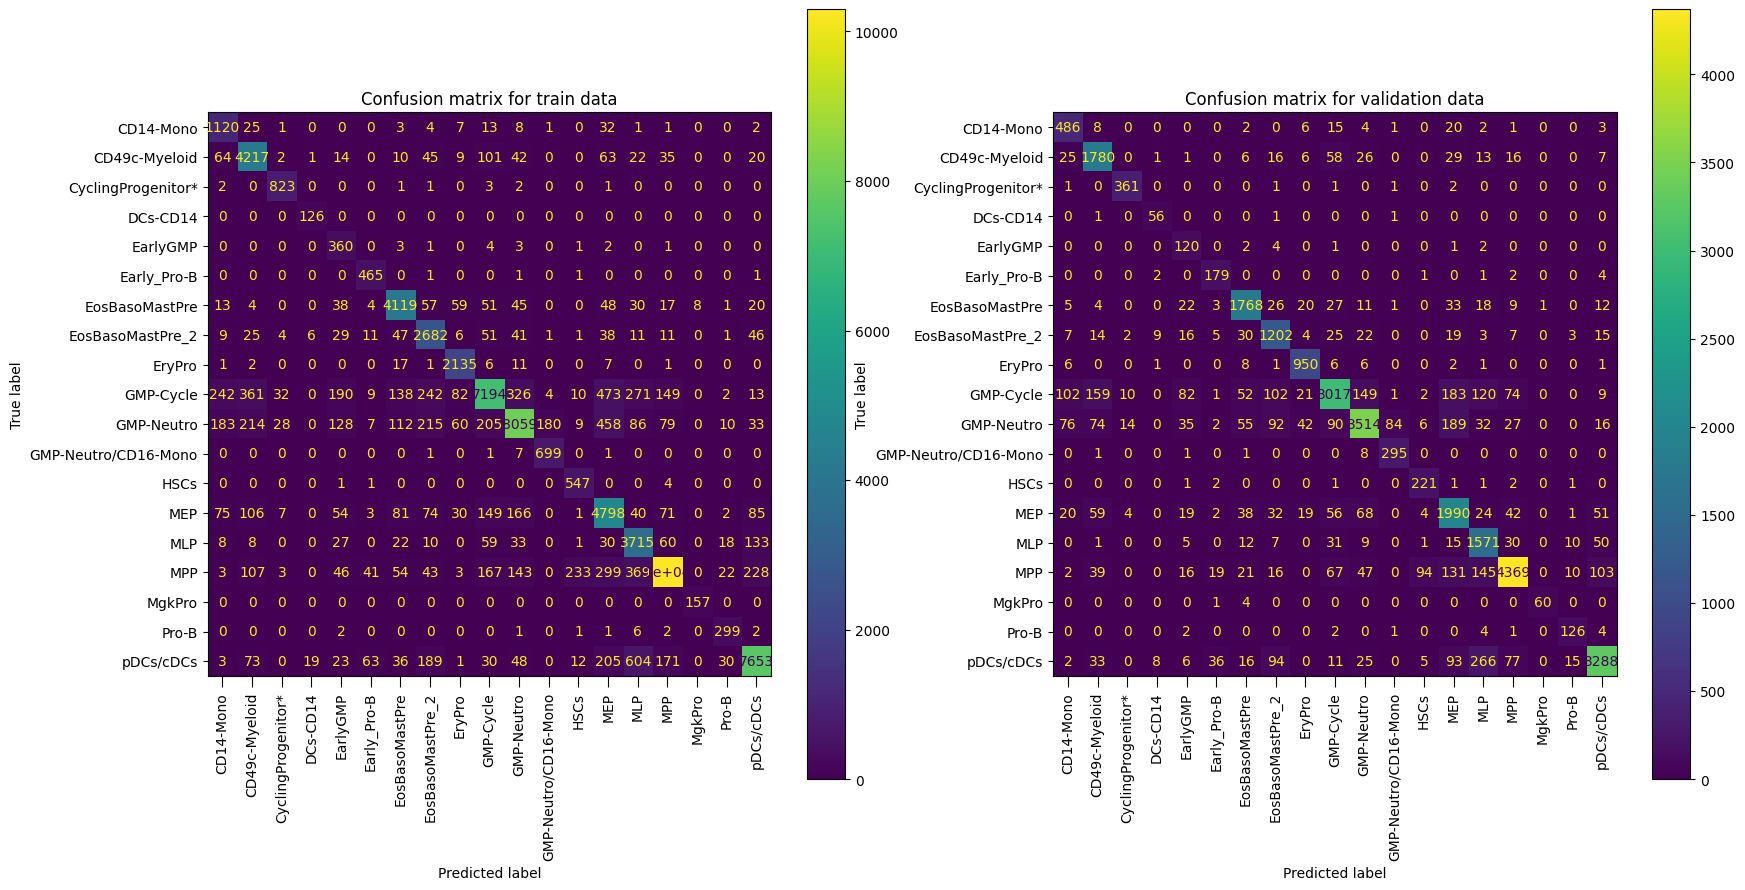

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
train_cmd = ConfusionMatrixDisplay(
    train_adata.uns["classification_results"]["cm"],
    display_labels=le_cell_type.classes_,
)
val_cmd = ConfusionMatrixDisplay(
    val_adata.uns["classification_results"]["cm"],
    display_labels=le_cell_type.classes_,
)
train_cmd.plot(ax=axes[0])
val_cmd.plot(ax=axes[1])

axes[0].tick_params("x", rotation=90, size=8)
axes[1].tick_params("x", rotation=90, size=8)

axes[0].set_title("Confusion matrix for train data")
axes[1].set_title("Confusion matrix for validation data")


### Manually setting the color map for the predicted cell types.

In [15]:
# Collect categories (they are the same, but we'll be explicit)
all_labels = train_adata.obs['cell_type'].cat.categories

# Build one palette
palette = sns.color_palette("tab20", n_colors=len(all_labels))
label2color = dict(zip(all_labels, palette))

# Function to assign consistent colors
def set_colors(adata, col, mapping):
    if not pd.api.types.is_categorical_dtype(adata.obs[col]):
        adata.obs[col] = adata.obs[col].astype("category")
    adata.uns[f"{col}_colors"] = [mapping[cat] for cat in adata.obs[col].cat.categories]

# Apply to both adatas and both columns
for adata in [train_adata, val_adata]:
    set_colors(adata, "cell_type", label2color)
    set_colors(adata, "predicted_cell_type", label2color)


/tmp/ipykernel_146613/702667748.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs[col]):
/tmp/ipykernel_146613/702667748.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs[col]):


### Displaying states.

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1148: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1148: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palet

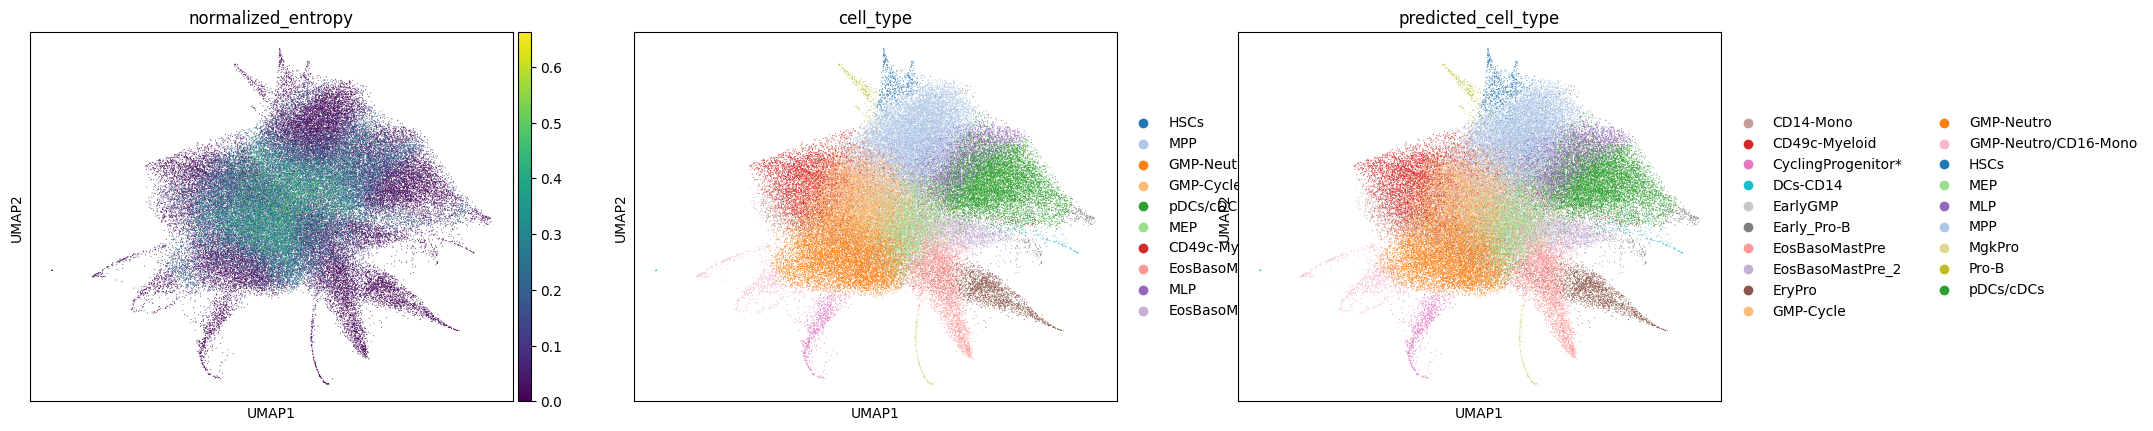

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1148: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1148: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palet

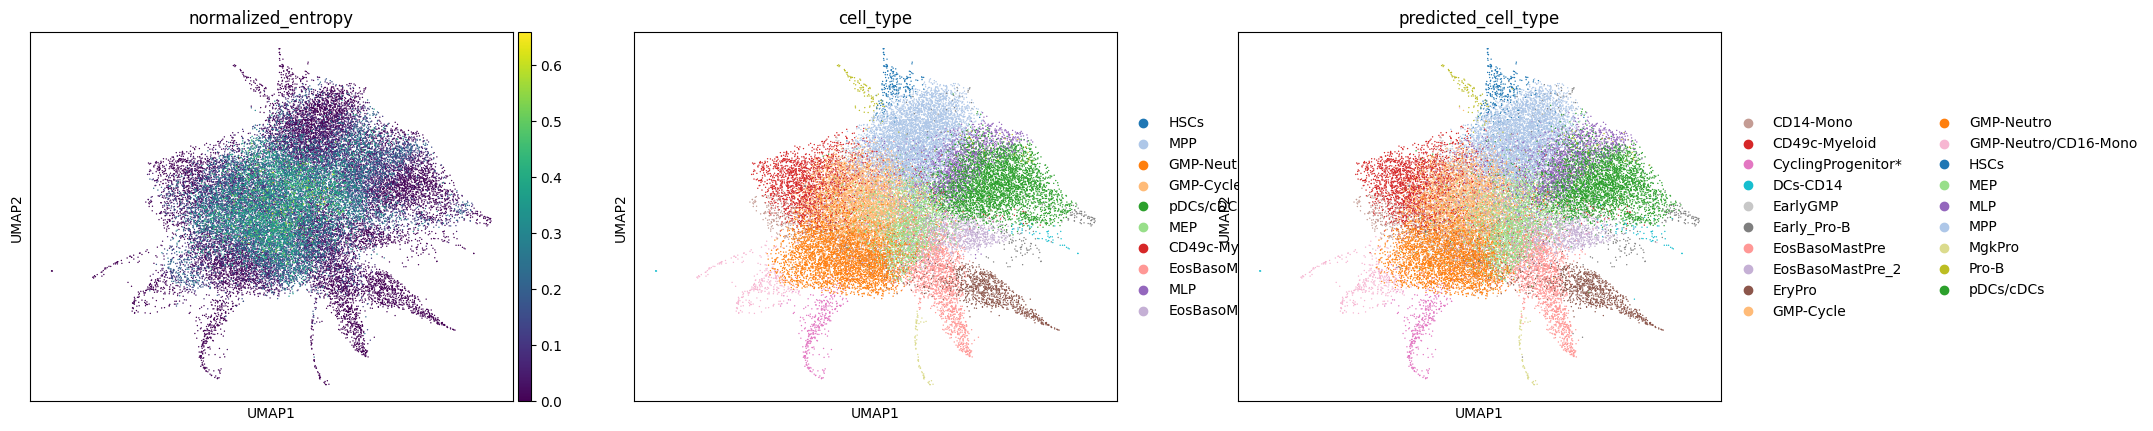

In [16]:
sc.pl.embedding(train_adata, "umap", color=["normalized_entropy", "cell_type", "predicted_cell_type"])
sc.pl.embedding(val_adata, "umap", color=["normalized_entropy", "cell_type", "predicted_cell_type"])


### Check LLR between HSCs and MPPs predicted probabilities for HSCs.

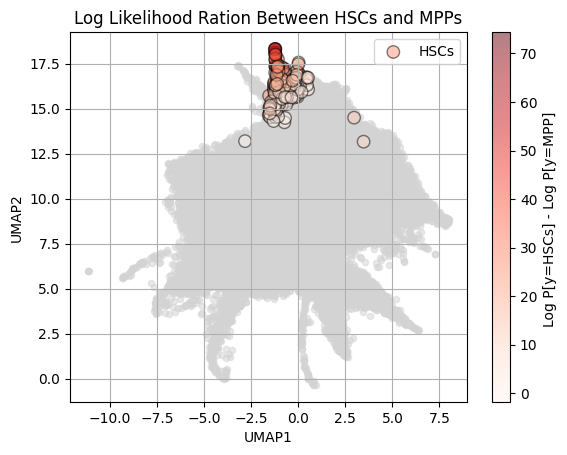

In [17]:
val_adata.obs["llr_HSCs_MPP_plt"] = Y_val_pred_log_probs[:, le_cell_type.transform(["HSCs"])] - Y_val_pred_log_probs[:, le_cell_type.transform(["MPP"]) ] 

# Extract UMAP coordinates
umap_coords = val_adata.obsm['X_umap']

# Mask for HSCs
hsc_mask = val_adata.obs['cell_type'] == 'HSCs'

# Values to color HSCs by
colors = val_adata.obs['llr_HSCs_MPP_plt']

# Plot all cells in grey
plt.scatter(
    umap_coords[:, 0],
    umap_coords[:, 1],
    c='lightgrey',  # background cells
    s=20,           # smaller size
    alpha=0.5
)

# Overlay HSCs with colored dots
plt.scatter(
    umap_coords[hsc_mask, 0],
    umap_coords[hsc_mask, 1],
    c=colors[hsc_mask],
    alpha=0.5,
    s=80,            # bigger dots
    cmap='Reds',     # or any cmap you prefer
    edgecolor='k',   # optional black border
    label='HSCs'
)

plt.title("Log Likelihood Ration Between HSCs and MPPs")
plt.colorbar(label='Log P[y=HSCs] - Log P[y=MPP] ')
plt.legend()
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.grid()
plt.show()


### Check LLR between HSCs and MPPs predicted probabilities for MPPs.

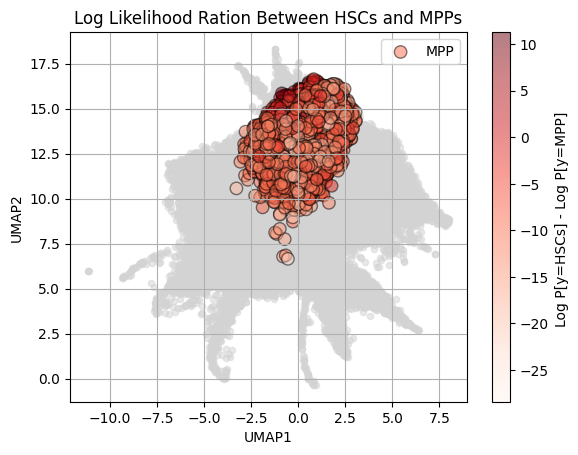

In [18]:
val_adata.obs["llr_HSCs_MPP_plt"] = Y_val_pred_log_probs[:, le_cell_type.transform(["HSCs"])] - Y_val_pred_log_probs[:, le_cell_type.transform(["MPP"]) ] 

# Extract UMAP coordinates
umap_coords = val_adata.obsm['X_umap']

# Mask for HSCs
mpp_mask = val_adata.obs['cell_type'] == 'MPP'

# Values to color HSCs by
colors = val_adata.obs['llr_HSCs_MPP_plt']

# Plot all cells in grey
plt.scatter(
    umap_coords[:, 0],
    umap_coords[:, 1],
    c='lightgrey',  # background cells
    s=20,           # smaller size
    alpha=0.5
)

# Overlay HSCs with colored dots
plt.scatter(
    umap_coords[mpp_mask, 0],
    umap_coords[mpp_mask, 1],
    c=colors[mpp_mask],
    alpha=0.5,
    s=80,            # bigger dots
    cmap='Reds',     # or any cmap you prefer
    edgecolor='k',   # optional black border
    label='MPP'
)

plt.title("Log Likelihood Ration Between HSCs and MPPs")
plt.colorbar(label='Log P[y=HSCs] - Log P[y=MPP] ')
plt.legend()
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.grid()
plt.show()


### 

### Visualize expression of HLA-DR antigen over manifold.

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1148: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


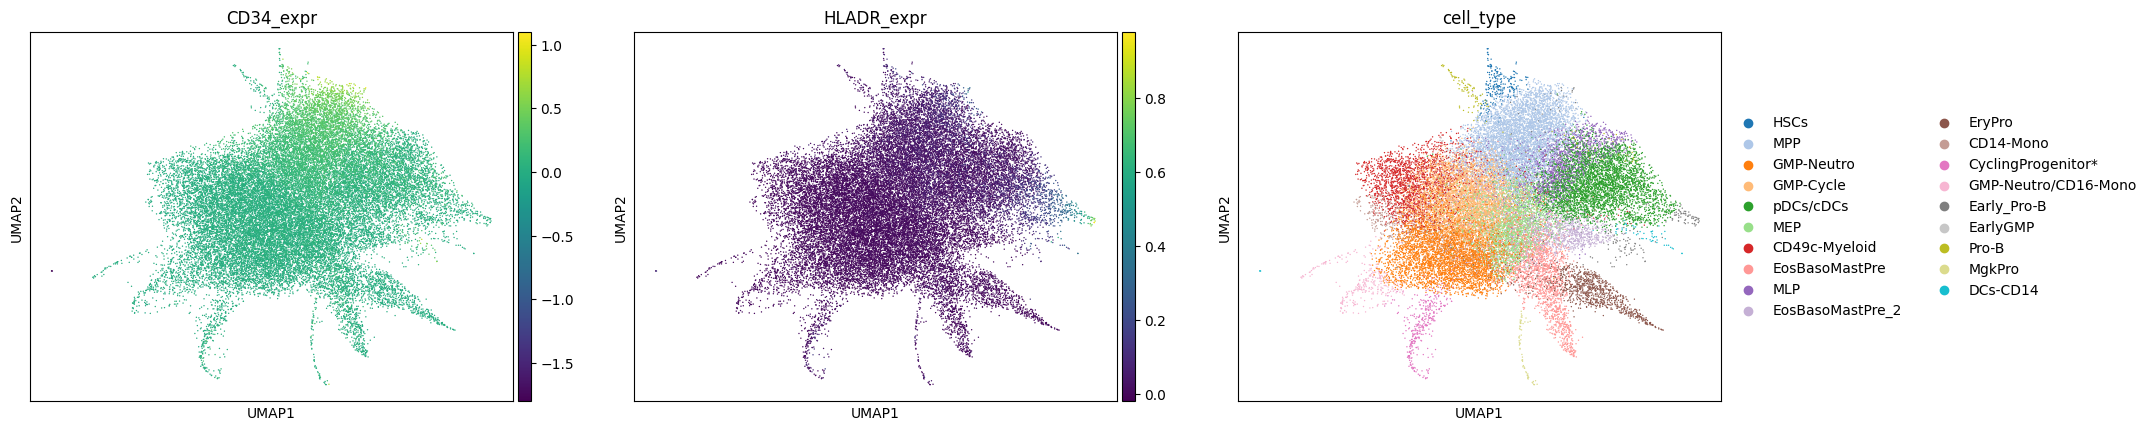

In [19]:
val_adata.obs["CD34_expr"] = val_adata[:, "CD34"].X.toarray()
val_adata.obs["HLADR_expr"] = val_adata[:, "HLADR"].X[:, 0].toarray()
sc.pl.embedding(val_adata,"umap", color=["CD34_expr", "HLADR_expr", "cell_type"])


### Checking correlation between CD34 antigen and predicted HSCs log probability.

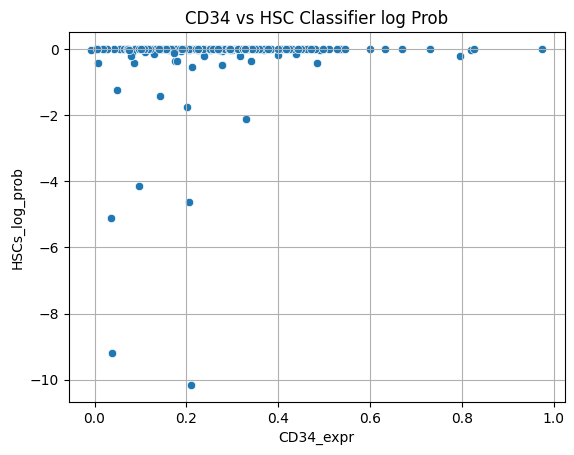

In [20]:
# Assuming 'score' is classifier output for HSC
val_adata.obs["HSCs_log_prob"] = Y_val_pred_log_probs[:, le_cell_type.transform(["HSCs"])]
sns.scatterplot(x='CD34_expr', y='HSCs_log_prob', data=adata.obs[adata.obs['cell_type'] == 'HSCs'])
plt.title("CD34 vs HSC Classifier log Prob")
plt.grid(True)
plt.show()


### Checking correlation between HLA-DR antigen and predicted HSCs log probability.

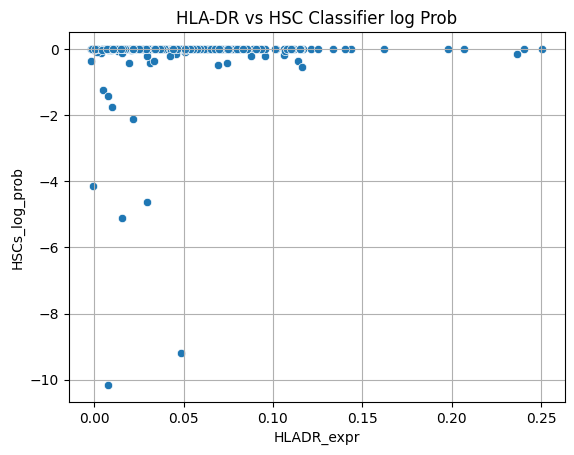

In [21]:
sns.scatterplot(x='HLADR_expr', y='HSCs_log_prob', data=adata.obs[adata.obs['cell_type'] == 'HSCs'])
plt.title("HLA-DR vs HSC Classifier log Prob")
plt.grid(True)
plt.show()


### Check distribution of HLA-DR antigen per cell type.

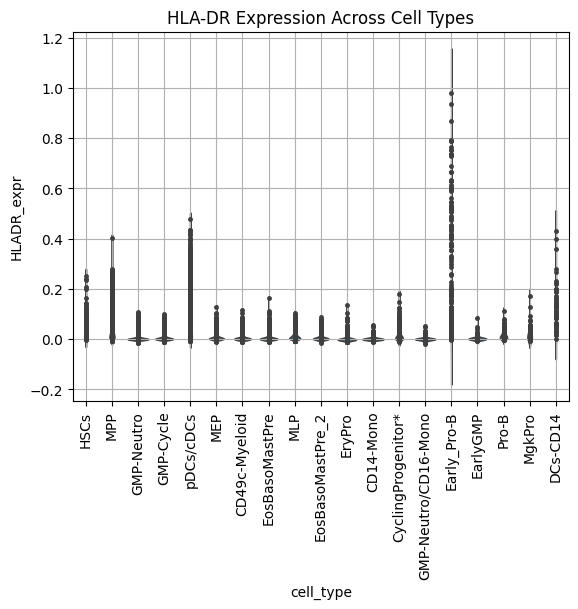

In [22]:
# Assume `data` is a DataFrame with 'cell_type' and 'HLADR' columns
sns.violinplot(x='cell_type', y='HLADR_expr', data=val_adata.obs, inner='point')
plt.title("HLA-DR Expression Across Cell Types")
plt.tick_params("x", rotation=90)
plt.grid(True)
plt.show()


### Checking distribution of CD34 antigen per cell type.

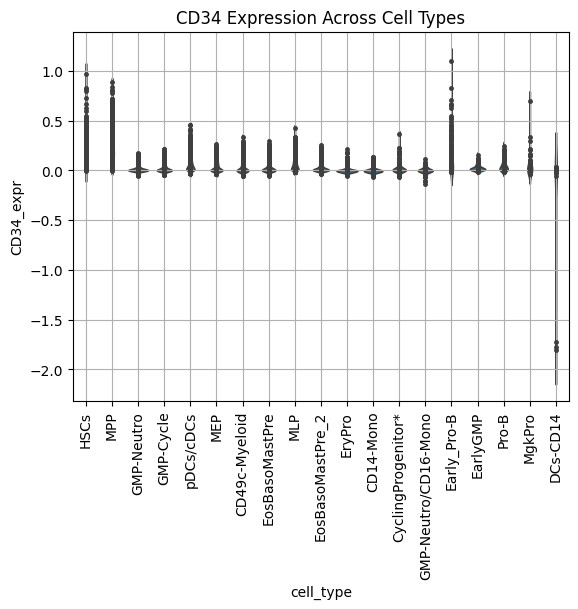

In [23]:
# Assume `data` is a DataFrame with 'cell_type' and 'HLADR' columns
sns.violinplot(x='cell_type', y='CD34_expr', data=val_adata.obs, inner='point')
plt.title("CD34 Expression Across Cell Types")
plt.tick_params("x", rotation=90)
plt.grid(True)
plt.show()


### Checking distribution of CD34 antigen in HSCs and MPPs.

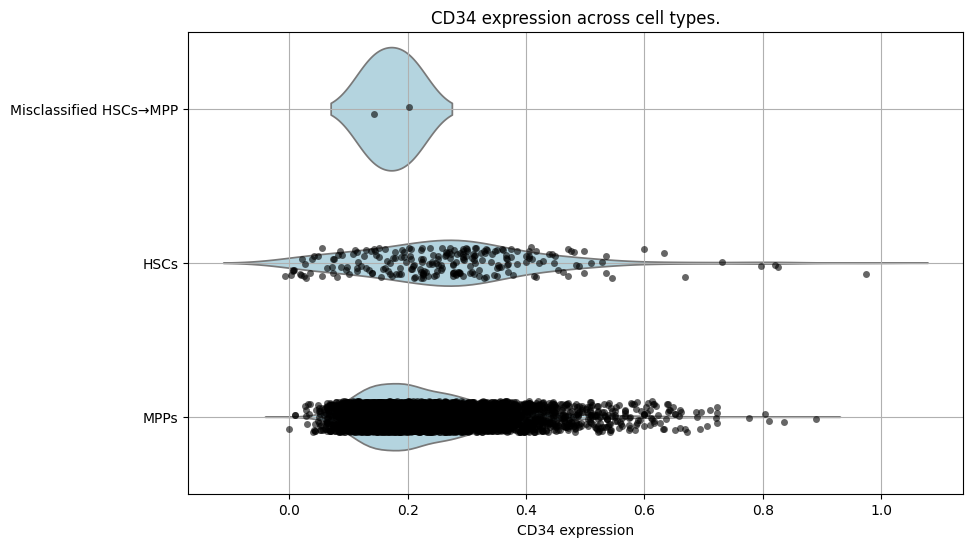

In [24]:
val_adata.obs["HSCs_predicted_as_MPP"] = (val_adata.obs["cell_type"] == "HSCs") & (val_adata.obs["predicted_cell_type"] == "MPP")
val_adata.obs["is_HSCs"] = val_adata.obs["cell_type"] == "HSCs"
val_adata.obs["is_MPP"] = val_adata.obs["cell_type"] == "MPP"
val_adata.obs["HSCs_predicted_as_MPP"].sum()

cd34_expr_misclassified_cells = val_adata[val_adata.obs["HSCs_predicted_as_MPP"], "CD34"].X[:, 0]
cd34_expr_HSCs = val_adata[val_adata.obs["is_HSCs"], "CD34"].X[:, 0]
cd34_expr_MPPs = val_adata[val_adata.obs["is_MPP"], "CD34"].X[:, 0]

# Combine data and labels
data = np.concatenate([cd34_expr_misclassified_cells, cd34_expr_HSCs, cd34_expr_MPPs])
labels = (["Misclassified HSCs→MPP"] * len(cd34_expr_misclassified_cells) +
          ["HSCs"] * len(cd34_expr_HSCs) +
          ["MPPs"] * len(cd34_expr_MPPs))

plt.figure(figsize=(10, 6))

# Horizontal barplot of median
# sns.barplot(x=data, y=labels, estimator=np.median, color="lightblue", ci=None)
sns.violinplot(x=data, y=labels, inner=None, color="lightblue")

# Overlay dots
sns.stripplot(x=data, y=labels, color="black", alpha=0.6, jitter=True, orient='h')

plt.xlabel("CD34 expression")
plt.ylabel("")
plt.title("CD34 expression across cell types.")

plt.grid(True)
plt.show()


### Visualizing HSCs misclassified as MPPs. 

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


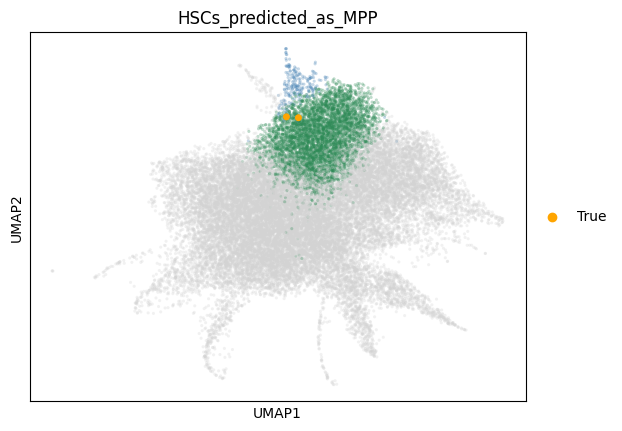

In [25]:
fig, ax = plt.subplots()
cell_types = val_adata.obs["cell_type"].cat.categories.tolist()  # all categories
palette = {ct: "lightgray" for ct in cell_types}                 # default gray
palette.update({
    "HSCs": "steelblue",   # HSCs = blue
    "MPP": "seagreen",     # MPPs = green
})
# 1. Plot background (all cells), color by true cell type (HSC vs MPP vs other)
sc.pl.embedding(
    val_adata,
    basis="umap",
    color="cell_type",   # show cell types
    size=20,
    alpha=0.3,
    ax=ax,
    show=False,
    legend_loc=None,     # suppress legend
    palette=palette
)

# 2. Overlay misclassified HSCs (highlight in orange)
sc.pl.embedding(
    val_adata[val_adata.obs["HSCs_predicted_as_MPP"]],
    basis="umap",
    color="HSCs_predicted_as_MPP",
    size=100,
    alpha=1.0,
    ax=ax,
    show=False,
    # legend_loc=None,      # suppress repeated legend
    palette={"True": "orange"}
)

plt.show()


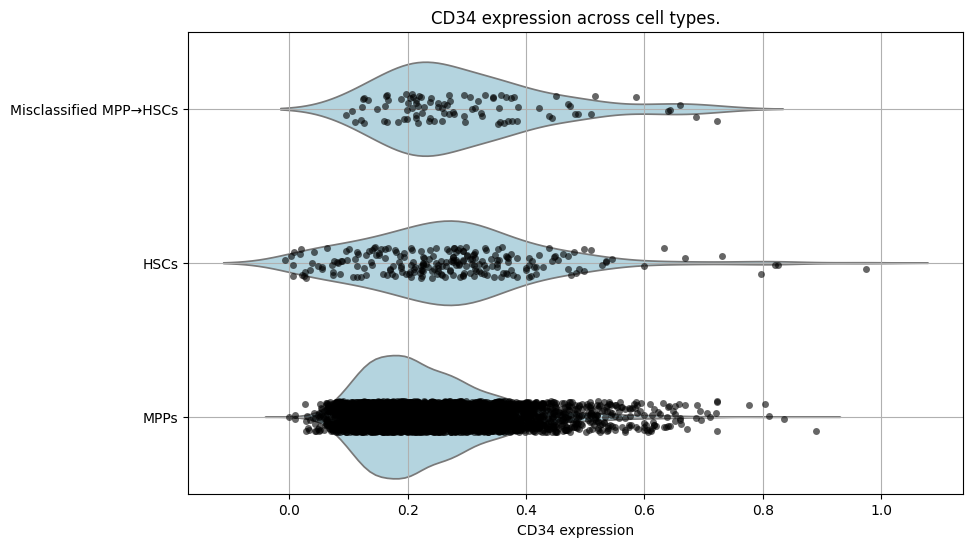

In [26]:
val_adata.obs["MPPs_predicted_as_HSCs"] = (val_adata.obs["cell_type"] == "MPP") & (val_adata.obs["predicted_cell_type"] == "HSCs")
val_adata.obs["is_HSCs"] = val_adata.obs["cell_type"] == "HSCs"
val_adata.obs["is_MPP"] = val_adata.obs["cell_type"] == "MPP"
val_adata.obs["HSCs_predicted_as_MPP"].sum()

cd34_expr_misclassified_cells = val_adata[val_adata.obs["MPPs_predicted_as_HSCs"], "CD34"].X[:, 0]
cd34_expr_HSCs = val_adata[val_adata.obs["is_HSCs"], "CD34"].X[:, 0]
cd34_expr_MPPs = val_adata[val_adata.obs["is_MPP"], "CD34"].X[:, 0]

# Combine data and labels
data = np.concatenate([cd34_expr_misclassified_cells, cd34_expr_HSCs, cd34_expr_MPPs])
labels = (["Misclassified MPP→HSCs"] * len(cd34_expr_misclassified_cells) +
          ["HSCs"] * len(cd34_expr_HSCs) +
          ["MPPs"] * len(cd34_expr_MPPs))

plt.figure(figsize=(10, 6))

# Horizontal barplot of median
# sns.barplot(x=data, y=labels, estimator=np.median, color="lightblue", ci=None)
sns.violinplot(x=data, y=labels, inner=None, color="lightblue")

# Overlay dots
sns.stripplot(x=data, y=labels, color="black", alpha=0.6, jitter=True, orient='h')

plt.xlabel("CD34 expression")
plt.ylabel("")
plt.title("CD34 expression across cell types.")

plt.grid(True)
plt.show()


### Visualizing MPPs misclassified as HSCs.

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


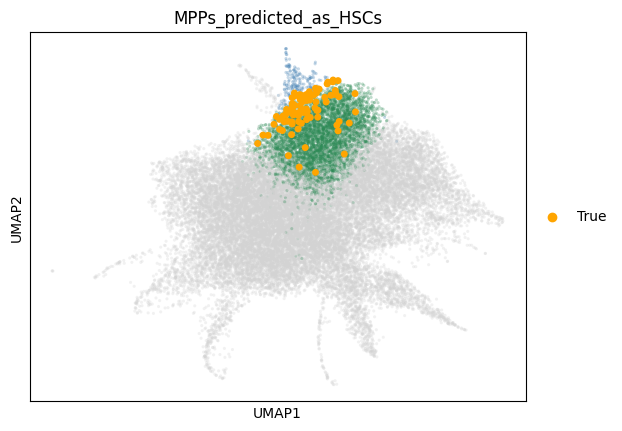

In [27]:
fig, ax = plt.subplots()
cell_types = val_adata.obs["cell_type"].cat.categories.tolist()  # all categories
palette = {ct: "lightgray" for ct in cell_types}                 # default gray
palette.update({
    "HSCs": "steelblue",   # HSCs = blue
    "MPP": "seagreen",     # MPPs = green
})
# 1. Plot background (all cells), color by true cell type (HSC vs MPP vs other)
sc.pl.embedding(
    val_adata,
    basis="umap",
    color="cell_type",   # show cell types
    size=20,
    alpha=0.3,
    ax=ax,
    show=False,
    legend_loc=None,     # suppress legend
    palette=palette
)

# 2. Overlay misclassified HSCs (highlight in orange)
sc.pl.embedding(
    val_adata[val_adata.obs["MPPs_predicted_as_HSCs"]],
    basis="umap",
    color="MPPs_predicted_as_HSCs",
    size=100,
    alpha=1.0,
    ax=ax,
    show=False,
    # legend_loc=None,      # suppress repeated legend
    palette={"True": "orange"}
)

plt.show()


### Inspecting Confusion Matrix on train data. 

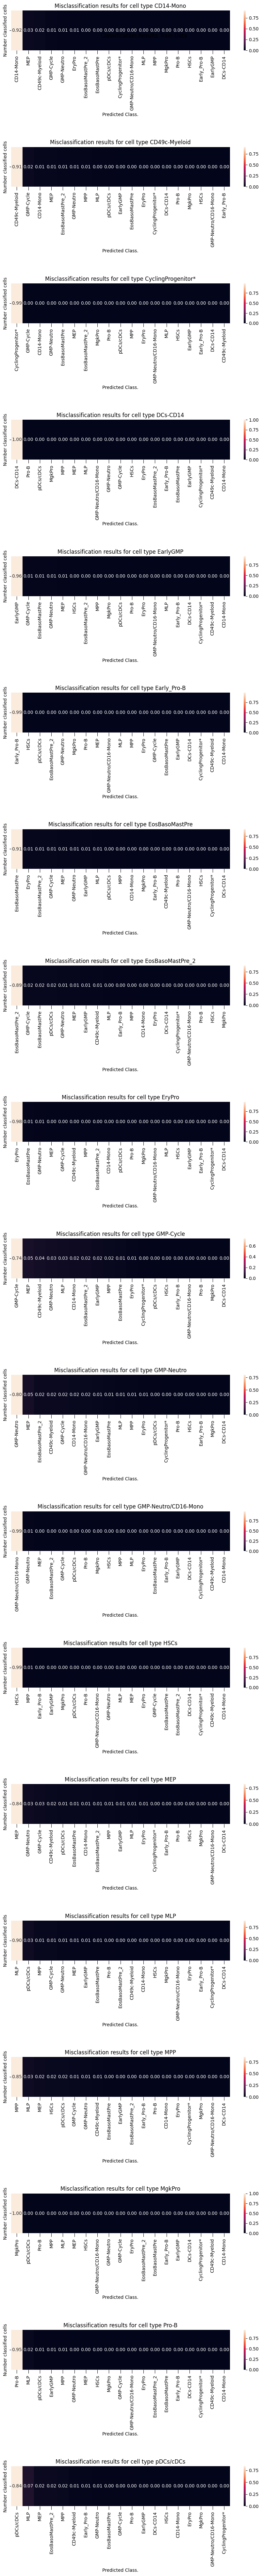

In [28]:
def inspect_confusion_matrix(cm, normalize=True):
    # cm_train = train_adata.uns["classification_results"]["cm"]
    sorted_idxs = np.argsort(cm, axis=-1)

    fig, axes = plt.subplots(Y_train_pred_probs.shape[1], 1, figsize=(10, 80))
    for idx in range(Y_train_pred_probs.shape[1]):
        current_cell_type = le_cell_type.inverse_transform(np.array([idx]))
        confounded_cell_types_idxs = np.flip(sorted_idxs[idx])
        confounded_cell_types = le_cell_type.inverse_transform(confounded_cell_types_idxs)
        num_preds = cm[idx, confounded_cell_types_idxs]
        if normalize:
            num_preds = num_preds / num_preds.sum()
        axes[idx].set_title(f"Misclassification results for cell type {current_cell_type[0]}")
        sns.heatmap(num_preds[None], ax=axes[idx], xticklabels=confounded_cell_types, yticklabels=["Number classified cells"], annot=True, fmt=".2f" if normalize else "d")
        axes[idx].tick_params("x", size=8)
        axes[idx].set_xlabel("Predicted Class.")
    # plt.subplots_adjust(hspace=2.0)
    fig.tight_layout(pad=5.0)
    return fig, axes

fig, axes = inspect_confusion_matrix(train_adata.uns["classification_results"]["cm"])
fig.suptitle("Classification Results Train Data")
fig.show()


### Inspecting Confusion Matrix on Validation Data.

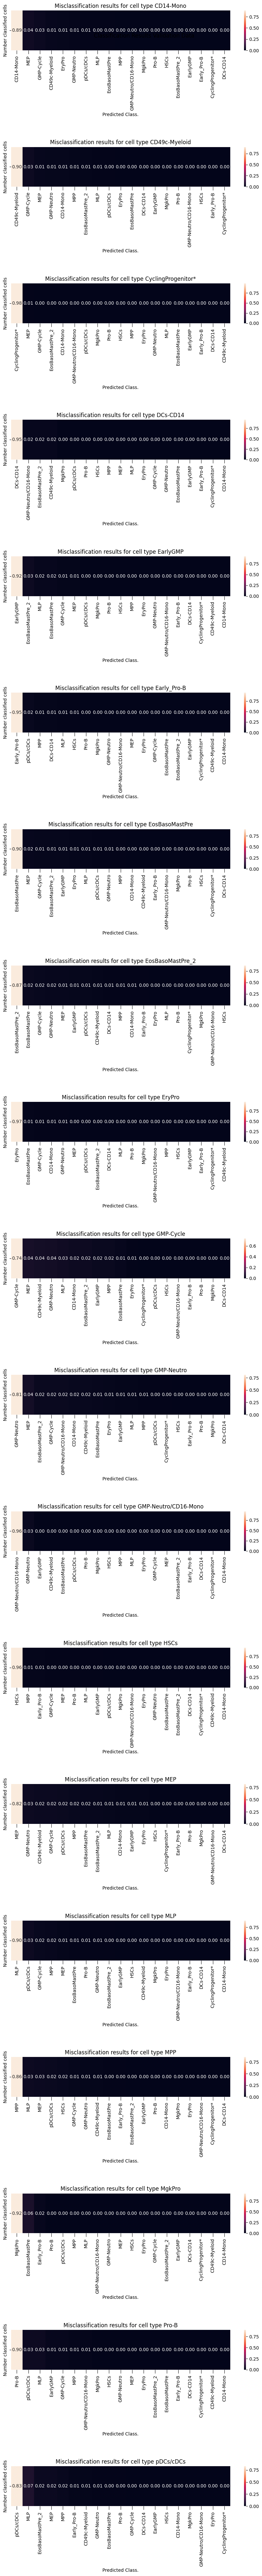

In [29]:
fig, axes = inspect_confusion_matrix(val_adata.uns["classification_results"]["cm"])
fig.suptitle("Classification Results Validation Data")
fig.show()


### Check Gradients.

In [ ]:
# def predict(X_val):
#     return mlp_target_prediction_model(X_val.float().cuda())["cell_type"]
# # out, grad = torch.autograd.functional.vjp(predict, torch.from_numpy(X_val).float().cuda(), torch.ones(X_val.shape[0], Y_train_pred_logits.shape[-1],device="cuda"))
# out, grad = torch.autograd.functional.jacobian(predict, torch.from_numpy(X_val).float().cuda(),vectorize=True)

out.shape, grad.shape


OutOfMemoryError: CUDA out of memory. Tried to allocate 1210.35 GiB. GPU 0 has a total capacity of 19.62 GiB of which 19.25 GiB is free. Including non-PyTorch memory, this process has 266.00 MiB memory in use. Of the allocated memory 30.59 MiB is allocated by PyTorch, and 11.41 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)